In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)


import gzip
import struct

def load_mnist_images(path, limit=None):
    with gzip.open(path, "rb") as fh:
        magic, count, rows, cols = struct.unpack(">IIII", fh.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number: {magic}")
        if limit is None:
            limit = count
        data = np.frombuffer(fh.read(rows * cols * limit), dtype=np.uint8)
    return data.reshape(limit, rows, cols).astype("float32") / 255.0

def load_mnist_labels(path, limit=None):
    with gzip.open(path, "rb") as fh:
        magic, count = struct.unpack(">II", fh.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number: {magic}")
        if limit is None:
            limit = count
        return np.frombuffer(fh.read(limit), dtype=np.uint8)

In [2]:
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

tf.random.set_seed(RANDOM_STATE)

train_images = load_mnist_images(DATA_DIR / "mnist/train-images-idx3-ubyte.gz", limit=10000)[..., None]
train_labels = load_mnist_labels(DATA_DIR / "mnist/train-labels-idx1-ubyte.gz", limit=10000)
test_images = load_mnist_images(DATA_DIR / "mnist/t10k-images-idx3-ubyte.gz", limit=2000)[..., None]
test_labels = load_mnist_labels(DATA_DIR / "mnist/t10k-labels-idx1-ubyte.gz", limit=2000)
print(train_images.shape, test_images.shape)

I0000 00:00:1776648543.336914   36604 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776648543.337224   36604 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776648543.367048   36604 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1776648544.192126   36604 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776648544.192356   36604 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(10000, 28, 28, 1) (2000, 28, 28, 1)


In [3]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(24, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(48, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(
    train_images,
    train_labels,
    validation_split=0.15,
    epochs=3,
    batch_size=128,
    verbose=1,
)

Epoch 1/3


E0000 00:00:1776648545.041582   36604 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected



 1/67 ━━━━━━━━━━━━━━━━━━━━ 36s 559ms/step - accuracy: 0.0938 - loss: 2.3042


 7/67 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2018 - loss: 2.2595   


14/67 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2748 - loss: 2.1948

...


40/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9387 - loss: 0.2173


47/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9392 - loss: 0.2158


55/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9396 - loss: 0.2142


63/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9401 - loss: 0.2124


67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9453 - loss: 0.1955 - val_accuracy: 0.9433 - val_loss: 0.1828


Test accuracy: 0.950


              precision    recall  f1-score   support

           0       0.95      0.99      0.97       175
           1       0.99      0.99      0.99       234
           2       0.94      0.96      0.95       219
           3       0.92      0.98      0.95       207
           4       0.97      0.95      0.96       217
           5       0.97      0.96      0.96       179
           6       0.97      0.96      0.96       178
           7       0.92      0.92      0.92       205
           8       0.96      0.83      0.89       192
           9       0.92      0.95      0.94       194

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



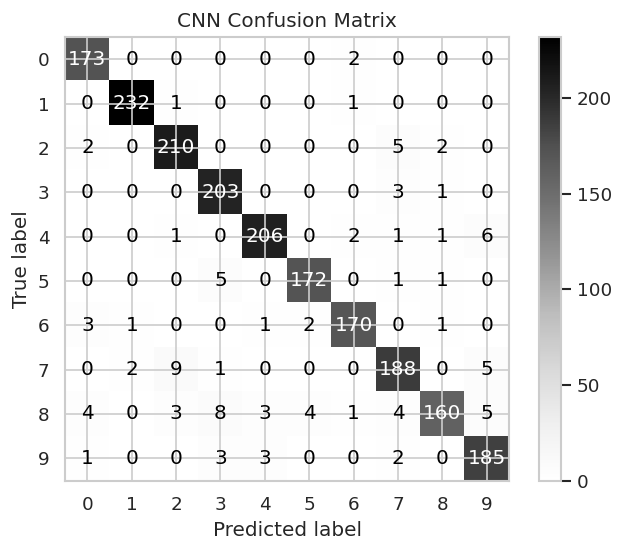

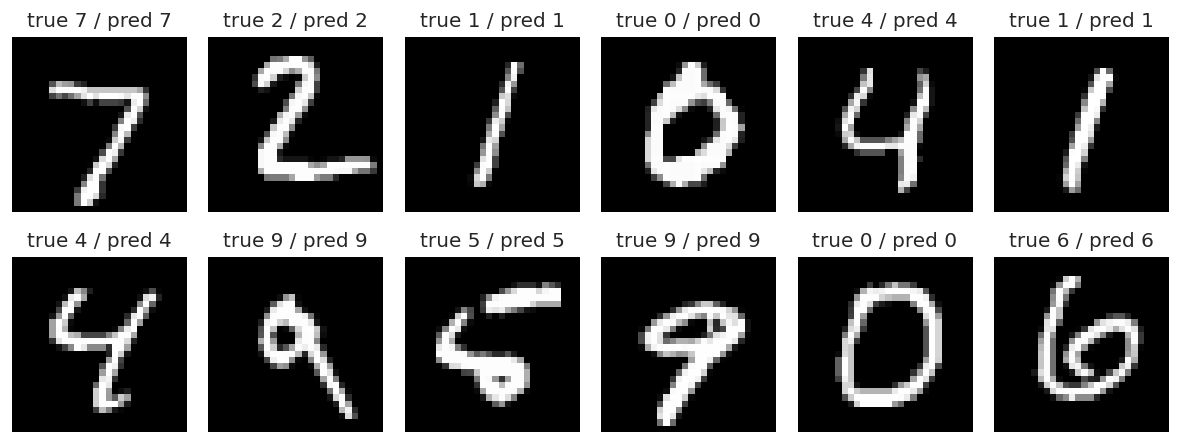

In [4]:
loss, acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {acc:.3f}")
pred = model.predict(test_images, verbose=0).argmax(axis=1)
print(classification_report(test_labels, pred))
ConfusionMatrixDisplay.from_predictions(test_labels, pred, cmap="Greys")
plt.title("CNN Confusion Matrix")
plt.show()

sample_idx = np.arange(12)
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(test_images[idx].squeeze(), cmap="gray")
    ax.set_title(f"true {test_labels[idx]} / pred {pred[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()